In [1]:
# --- Basic Libraries ---
import os
import cv2
import torch
import pickle
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import time
from PIL import Image
from torchvision import transforms
import face_recognition

# --- Firebase & Mongo ---
import firebase_admin
from firebase_admin import credentials, db
from pymongo import MongoClient

# --- Jupyter Display ---
from IPython.display import display, Markdown

# Set display options
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "trained_models/antispoof_fullmodels.pkl"

def load_models():
    t0 = time.perf_counter()
    models_dict = torch.load(model_path, map_location=device, weights_only=False)
    for name, model in models_dict.items():
        model.to(device)
        model.eval()
    t1 = time.perf_counter()
    print(f"[TIMING] Model load time: {t1 - t0:.4f} sec")
    return models_dict

models_dict = load_models()

# Transform for anti-spoofing
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load face encodings
with open("ENcodedFile.p", "rb") as file:
    encodeAndIdList = pickle.load(file)
encode, studentIDs = encodeAndIdList

print(f"✅ Loaded {len(encode)} known face encodings.")


[TIMING] Model load time: 0.0903 sec
✅ Loaded 8 known face encodings.


In [3]:
def is_real_face(face_img):
    """Returns (is_real: bool, inference_time: float)"""
    pil_img = Image.fromarray(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
    img_tensor = transform(pil_img).unsqueeze(0).to(device)
    
    t0 = time.perf_counter()
    probs_sum = None
    with torch.no_grad():
        for name, model in models_dict.items():
            output = model(img_tensor)
            probs = torch.softmax(output, dim=1)
            probs_sum = probs if probs_sum is None else probs_sum + probs
    avg_probs = probs_sum / len(models_dict)
    pred_class = torch.argmax(avg_probs, dim=1).item()
    t1 = time.perf_counter()
    
    return pred_class == 1, t1 - t0  # 1=real, 0=spoof


In [4]:
# Replace with your test image path
image_path = "single_test_photo.jpg"
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Detect faces
face_locations = face_recognition.face_locations(img_rgb)
print(f"Detected {len(face_locations)} face(s)")


Detected 2 face(s)


In [5]:
def crop_face_with_padding(img, location, padding=20):
    top, right, bottom, left = location
    h, w = img.shape[:2]
    # add padding and clamp to image boundaries
    top = max(0, top - padding)
    left = max(0, left - padding)
    bottom = min(h, bottom + padding)
    right = min(w, right + padding)
    return img[top:bottom, left:right]

# Crop all faces
cropped_faces = [crop_face_with_padding(img_rgb, loc, padding=300) for loc in face_locations]


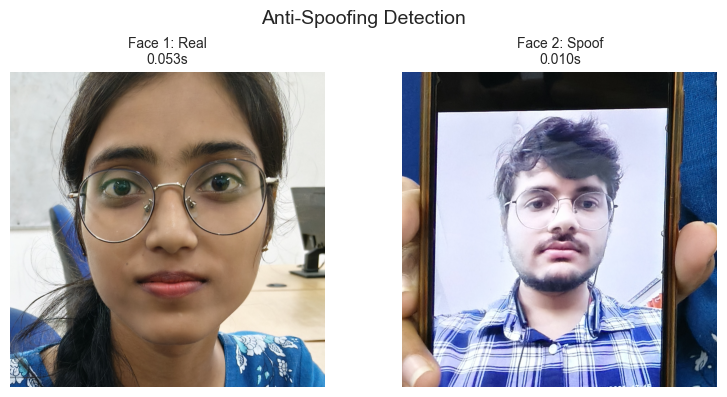

In [6]:
import math

n_faces = len(cropped_faces)
ncols = min(3, n_faces)           # max 3 faces per row
nrows = math.ceil(n_faces / ncols)  # compute required rows

plt.figure(figsize=(4*ncols, 4*nrows))  # width x height

for i, face_crop in enumerate(cropped_faces):
    is_real, t_infer = is_real_face(face_crop)
    label = "Real" if is_real else "Spoof"
    
    plt.subplot(nrows, ncols, i+1)
    plt.imshow(face_crop)
    plt.title(f"Face {i+1}: {label}\n{t_infer:.3f}s", fontsize=10)
    plt.axis("off")

plt.suptitle("Anti-Spoofing Detection", fontsize=14)
plt.tight_layout()
plt.show()


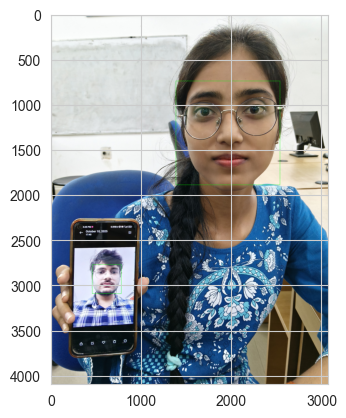

In [13]:
for loc in face_locations:
    top, right, bottom, left = loc
    color = (0,255,0)  # green for real (update after prediction)
    cv2.rectangle(img_rgb, (left, top), (right, bottom), color, 2)
plt.imshow(img_rgb)
plt.show()
